# Feature Selection для модели сегментации клиентов

**Цель:** Выявить лучшие признаки для кластеризации клиентов санатория.  
**Бизнес-связь:** Качественные признаки → осмысленные сегменты → точечный маркетинг → заполнение недозагруженности.

### Логика отбора
Хороший признак для кластеризации должен:
1. Быть **информативным** (высокая вариация, нет доминирующего значения)
2. Быть **достаточно заполненным** (< 40% пропусков)
3. Иметь **бизнес-смысл** для описания поведения/профиля клиента
4. Быть **независимым** от других признаков (без дублирования)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

df_raw = pd.read_csv('silver.csv')
for c in ['created_dt', 'check_in_dt', 'check_out_dt', 'activity_dt']:
    df_raw[c] = pd.to_datetime(df_raw[c], errors='coerce')

print(f'Raw shape: {df_raw.shape}')
print(f'is_valid_for_rfm=1 (known guests): {(df_raw["is_valid_for_rfm"]==1).sum():,}')
print(f'is_valid_for_rfm=0 (anonymous):     {(df_raw["is_valid_for_rfm"]==0).sum():,}')

Raw shape: (565816, 24)
is_valid_for_rfm=1 (known guests): 521,143
is_valid_for_rfm=0 (anonymous):     44,673


## 1. Фильтрация: только известные гости

Для **сегментации клиентов** нужен `guest_id` — иначе невозможно отследить повторные визиты и поведение.  
Анонимные записи (`is_valid_for_rfm=0`) оставим для модели **прогноза спроса** (там guest_id не нужен).

In [2]:
df = df_raw[df_raw['is_valid_for_rfm'] == 1].copy()
df = df.reset_index(drop=True)
print(f'Working dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

Working dataset: 521,143 rows, 24 columns


## 2. Feature Engineering — производные признаки

Из сырых полей извлекаем поведенческие и временные признаки.

In [3]:
# ── Временные признаки ──────────────────────────────────────────────────────
df['stay_duration'] = (df['check_out_dt'] - df['check_in_dt']).dt.days
df['lead_time']     = (df['check_in_dt']  - df['created_dt']).dt.days
df['check_in_month'] = df['check_in_dt'].dt.month
df['check_in_dow']   = df['check_in_dt'].dt.dayofweek   # 0=пн, 6=вс
df['check_in_year']  = df['check_in_dt'].dt.year

# Сезон (бизнес-смысл: высокий / низкий / межсезонье)
def month_to_season(m):
    if m in [6, 7, 8]:     return 'high'      # лето — пик
    if m in [12, 1, 2]:    return 'winter'     # зима — средний
    if m in [3, 4, 5]:     return 'spring'     # весна
    return                        'autumn'      # осень
df['season'] = df['check_in_month'].map(month_to_season)

# ── Тарифные группы (628 → ~8 групп) ───────────────────────────────────────
def group_tariff(t):
    if pd.isna(t): return 'other'
    t = t.lower()
    if any(k in t for k in ['фсс', 'гку', 'согаз', 'дирекци', 'путёвки', 'путевки']):
        return 'льготный/корп'          # соцпакеты, ГКУ, страховые
    if any(k in t for k in ['ультра', 'все включено', 'all inclusive']):
        return 'ультра/all-incl'        # максимальный пакет
    if 'оптима' in t or 'стандарт' in t or 'межсезон' in t:
        return 'стандарт/оптима'
    if 'сезон' in t:
        return 'сезонный'
    if 'служеб' in t:
        return 'служебный'
    if 'лечени' in t or 'оздоров' in t or 'медицин' in t:
        return 'лечебный'
    if 'фестив' in t or 'новогод' in t or 'акци' in t:
        return 'акционный'
    return 'other'

df['tariff_group'] = df['tariff'].map(group_tariff)

# ── Тип номера — упрощённая группа ─────────────────────────────────────────
def group_room(r):
    if pd.isna(r): return 'other'
    r = r.lower()
    if 'стд' in r or 'стандарт' in r: return 'стандарт'
    if 'к+' in r or 'комфорт+' in r:  return 'комфорт+'
    if 'к-' in r or 'к -' in r or 'комфорт' in r: return 'комфорт'
    if 'люкс' in r or 'лк' in r:      return 'люкс'
    if 'апарт' in r or 'ап' in r:     return 'апартаменты'
    return 'other'

df['room_group'] = df['room_type'].map(group_room)

# ── Бинарные признаки ───────────────────────────────────────────────────────
df['has_discount']  = df['discount'].notna().astype(int)   # NaN = без скидки
df['is_foreign']    = (df['citizenship'].notna() & (df['citizenship'] != 'РОССИЯ')).astype(int)
df['has_children']  = (df['children'].fillna(0) > 0).astype(int)
df['is_repeat']     = (df['prev_stays'].fillna(0) > 1).astype(int)   # был ли раньше
df['is_weekend_in'] = (df['check_in_dow'] >= 5).astype(int)           # заезд в выходные

# ── Очистка выбросов ────────────────────────────────────────────────────────
df.loc[df['stay_duration'] > 90, 'stay_duration'] = np.nan    # >3 мес — явная ошибка
df.loc[df['stay_duration'] < 0,  'stay_duration'] = np.nan
df.loc[df['lead_time'] < 0,      'lead_time']     = 0         # бронь после заезда → 0
df.loc[df['lead_time'] > 365,    'lead_time']     = 365
df.loc[df['guest_age'] > 100,    'guest_age']     = np.nan    # 999 и т.п.
df.loc[df['guest_age'] < 1,      'guest_age']     = np.nan
df.loc[df['prev_stays'] > 100,   'prev_stays']    = 100       # cap

print('Feature engineering done.')
print(f'New features: stay_duration, lead_time, check_in_month, check_in_dow, season,')
print(f'              tariff_group, room_group, has_discount, is_foreign, has_children,')
print(f'              is_repeat, is_weekend_in')

Feature engineering done.
New features: stay_duration, lead_time, check_in_month, check_in_dow, season,
              tariff_group, room_group, has_discount, is_foreign, has_children,
              is_repeat, is_weekend_in


## 3. Анализ пропусков по кандидатам в признаки

In [4]:
# Все кандидаты
CANDIDATES = {
    # Производные из дат
    'stay_duration':  'Длительность проживания (дни)',
    'lead_time':      'Заблаговременность бронирования (дни)',
    'check_in_month': 'Месяц заезда (1-12)',
    'check_in_dow':   'День недели заезда (0=пн)',
    'season':         'Сезон заезда',
    'is_weekend_in':  'Заезд в выходные (бинарный)',
    # Продуктовые предпочтения
    'tariff_group':   'Группа тарифа',
    'room_group':     'Группа типа номера',
    'has_discount':   'Наличие скидки (бинарный)',
    # Демография
    'guest_age':      'Возраст гостя',
    'gender':         'Пол гостя',
    'is_foreign':     'Иностранец (бинарный)',
    # Поведение/лояльность
    'prev_stays':     'Кол-во предыдущих визитов',
    'is_repeat':      'Повторный гость (бинарный)',
    'has_children':   'С детьми (бинарный)',
}

# Исключённые признаки (объяснение)
EXCLUDED = {
    'grp / grp_norm':    'Технический ID бронирования — не атрибут клиента',
    'rooms':             '95% пропусков — нет данных',
    'extra_places':      '81% пропусков — нет данных',
    'children (raw)':    '92% пропусков → заменён бинарным has_children',
    'adults (raw)':      '58% пропусков, почти всегда 1-2 — низкая вариация',
    'places (raw)':      '21% пропусков, почти всегда 1 — низкая вариация',
    'composition':       '58% пропусков + перекрывается has_children',
    'citizenship (raw)': '97% Россия — заменён бинарным is_foreign',
    'currency':          '96% Рублей — нет вариации',
    'tariff (raw)':      '628 уникальных значений → заменён tariff_group',
    'room_type (raw)':   '24 значения → заменён room_group',
    'guest_id / name':   'Идентификаторы, не признаки',
    'created/check dates (raw)': 'Заменены производными (stay_duration, lead_time, ...)',
}

null_pct = {c: df[c].isna().mean()*100 for c in CANDIDATES}
miss_df = pd.DataFrame({
    'Признак': list(CANDIDATES.keys()),
    'Описание': list(CANDIDATES.values()),
    'Пропусков %': [null_pct[c] for c in CANDIDATES],
})
miss_df['Статус'] = miss_df['Пропусков %'].apply(
    lambda x: '✓ OK' if x < 30 else ('~ Умеренно' if x < 50 else '✗ Много')
)
miss_df = miss_df.sort_values('Пропусков %')

print(miss_df[['Признак','Пропусков %','Статус','Описание']].to_string(index=False))

       Признак  Пропусков % Статус                              Описание
     lead_time     0.000000   ✓ OK Заблаговременность бронирования (дни)
check_in_month     0.000000   ✓ OK                   Месяц заезда (1-12)
  check_in_dow     0.000000   ✓ OK             День недели заезда (0=пн)
        season     0.000000   ✓ OK                          Сезон заезда
  tariff_group     0.000000   ✓ OK                         Группа тарифа
 is_weekend_in     0.000000   ✓ OK           Заезд в выходные (бинарный)
    room_group     0.000000   ✓ OK                    Группа типа номера
  has_discount     0.000000   ✓ OK             Наличие скидки (бинарный)
  has_children     0.000000   ✓ OK                   С детьми (бинарный)
    is_foreign     0.000000   ✓ OK                 Иностранец (бинарный)
     is_repeat     0.000000   ✓ OK            Повторный гость (бинарный)
 stay_duration     0.087692   ✓ OK         Длительность проживания (дни)
        gender    16.823789   ✓ OK                 

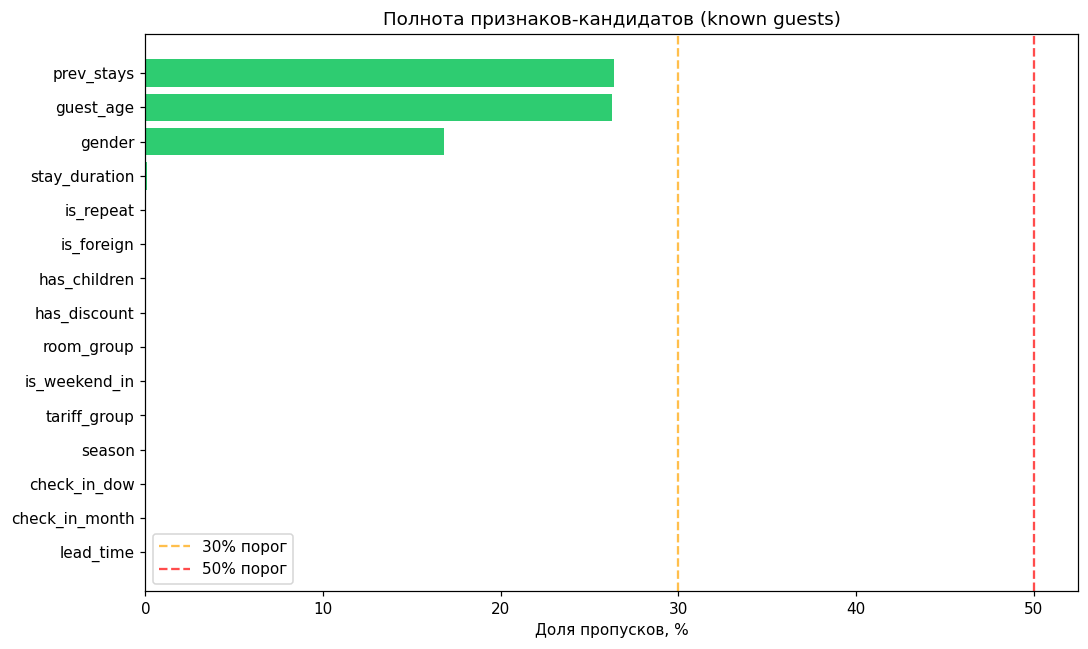

Зелёный = OK (<30%), Оранжевый = умеренно (30-50%), Красный = много (>50%)


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = miss_df['Статус'].map({'✓ OK': '#2ecc71', '~ Умеренно': '#f39c12', '✗ Много': '#e74c3c'})
bars = ax.barh(miss_df['Признак'], miss_df['Пропусков %'], color=colors)
ax.axvline(30, color='orange', linestyle='--', alpha=0.7, label='30% порог')
ax.axvline(50, color='red',    linestyle='--', alpha=0.7, label='50% порог')
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Полнота признаков-кандидатов (known guests)')
ax.legend()
plt.tight_layout()
plt.savefig('feature_nulls.png', dpi=120)
plt.show()
print('Зелёный = OK (<30%), Оранжевый = умеренно (30-50%), Красный = много (>50%)')

## 4. Распределение числовых признаков

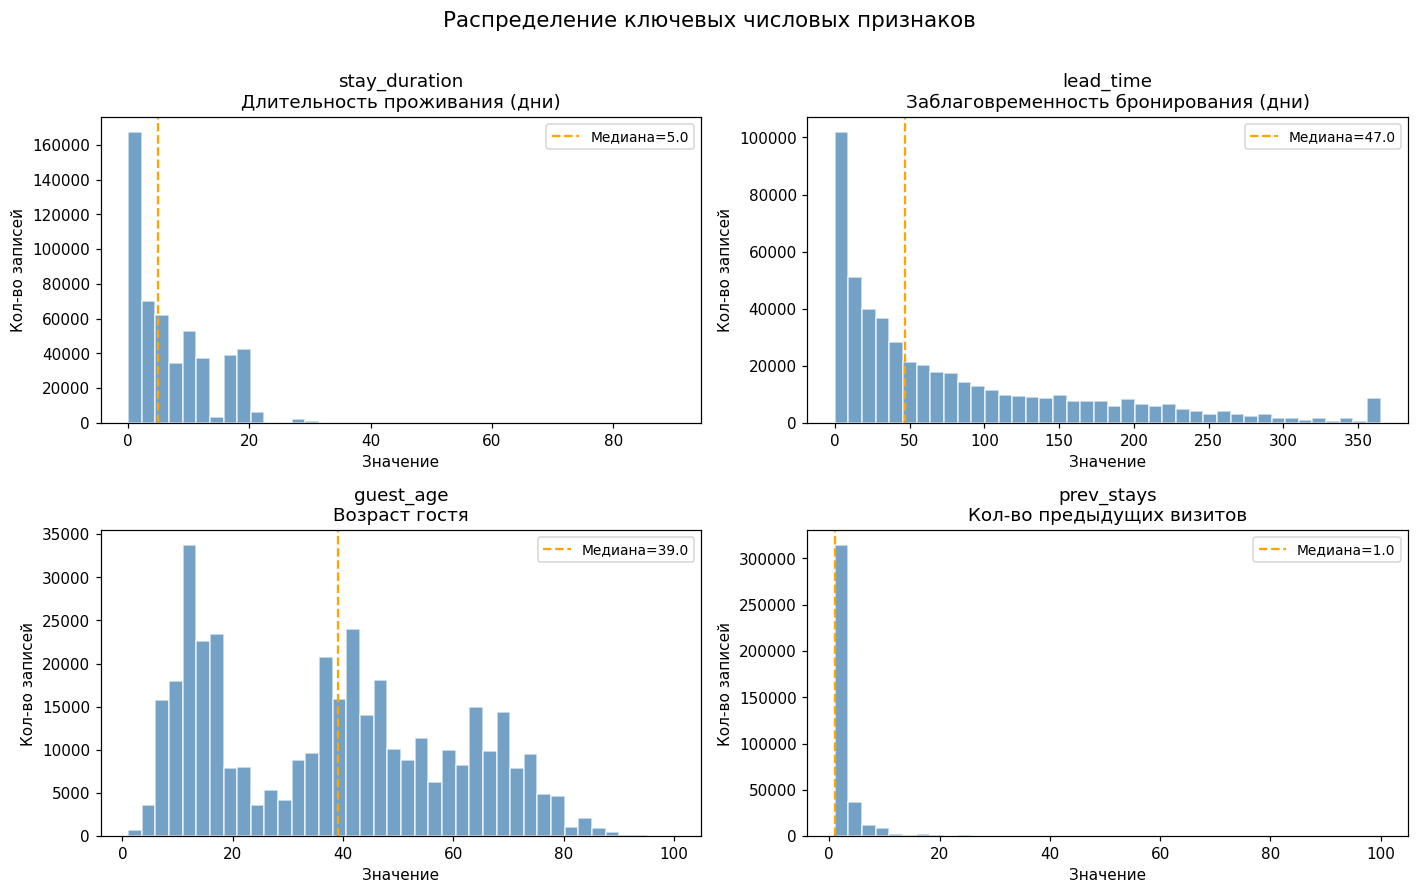

In [6]:
num_features = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

descriptions = {
    'stay_duration': 'Длительность проживания (дни)',
    'lead_time':     'Заблаговременность бронирования (дни)',
    'guest_age':     'Возраст гостя',
    'prev_stays':    'Кол-во предыдущих визитов',
}

for i, col in enumerate(num_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'{col}\n{descriptions[col]}')
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Кол-во записей')
    med = data.median()
    axes[i].axvline(med, color='orange', linestyle='--', label=f'Медиана={med:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Распределение ключевых числовых признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120)
plt.show()

## 5. Распределение категориальных признаков

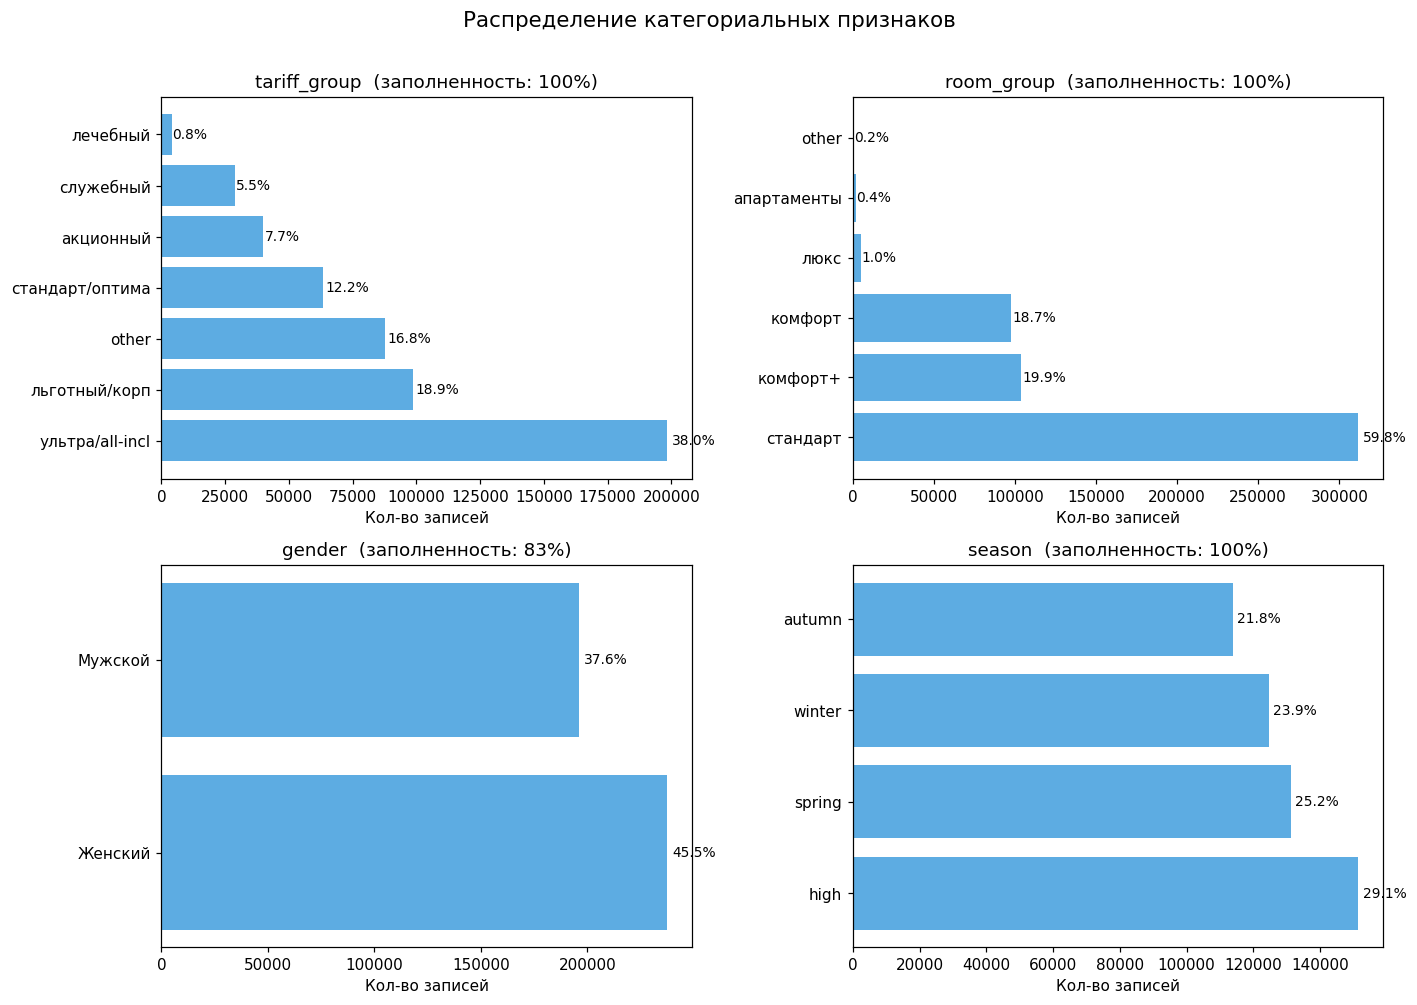

In [7]:
cat_features = ['tariff_group', 'room_group', 'gender', 'season']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    axes[i].barh(vc.index.astype(str), vc.values, color='#3498db', alpha=0.8)
    axes[i].set_title(f'{col}  (заполненность: {df[col].notna().mean()*100:.0f}%)')
    axes[i].set_xlabel('Кол-во записей')
    for bar, val in zip(axes[i].patches, vc.values):
        axes[i].text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                     f'{val/len(df)*100:.1f}%', va='center', fontsize=9)

plt.suptitle('Распределение категориальных признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_cat_dist.png', dpi=120)
plt.show()

## 6. Корреляционный анализ (числовые признаки)

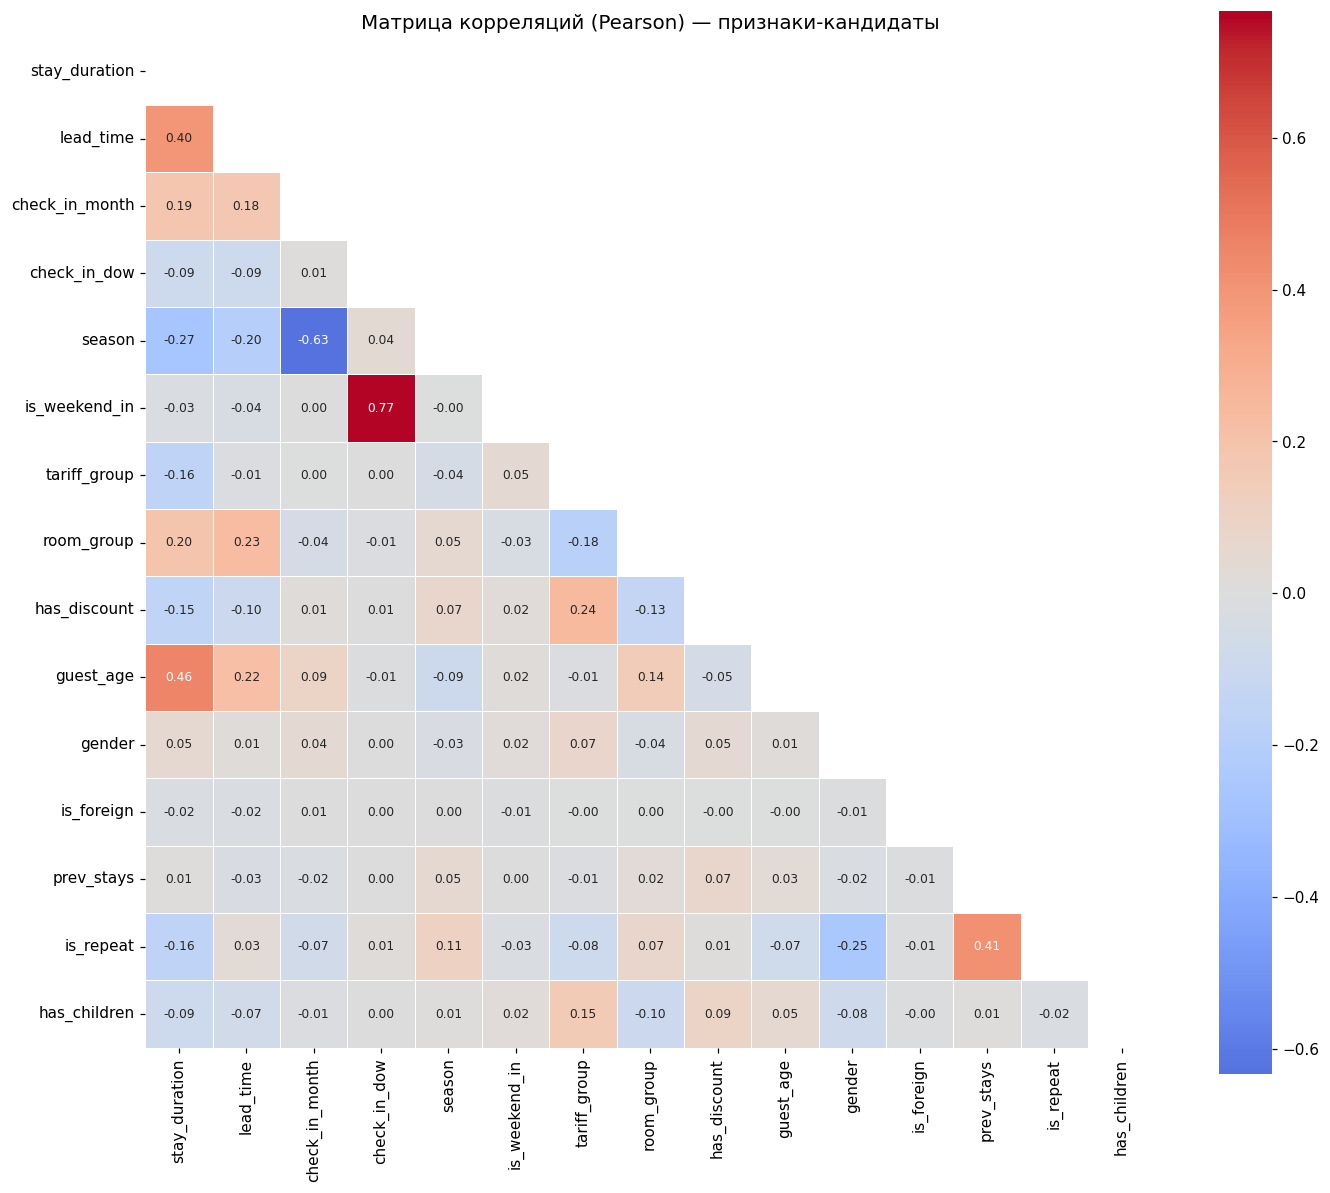

Высокие корреляции (|r| > 0.5) — возможное дублирование:
  check_in_dow <-> is_weekend_in:  r=0.767
  check_in_month <-> season:  r=0.633


In [8]:
# Кодируем категориальные для корреляции
df_enc = df[list(CANDIDATES.keys())].copy()

# Encode cats
for col in ['season', 'tariff_group', 'room_group', 'gender']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

corr = df_enc.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Матрица корреляций (Pearson) — признаки-кандидаты', fontsize=13)
plt.tight_layout()
plt.savefig('feature_corr.png', dpi=120)
plt.show()

# Найдём высокие корреляции (>0.5)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        c = abs(corr.iloc[i, j])
        if c > 0.5:
            high_corr.append((corr.columns[i], corr.columns[j], round(c,3)))

if high_corr:
    print('Высокие корреляции (|r| > 0.5) — возможное дублирование:')
    for a, b, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {a} <-> {b}:  r={r}')
else:
    print('Высоких корреляций между кандидатами не обнаружено — дублирования нет.')

## 7. Mutual Information — информативность каждого признака

Оцениваем, насколько каждый признак помогает предсказать **группу тарифа** (proxy-цель, отражающая ценовой сегмент клиента).  
MI > 0 означает, что признак несёт информацию. Чем выше — тем лучше.

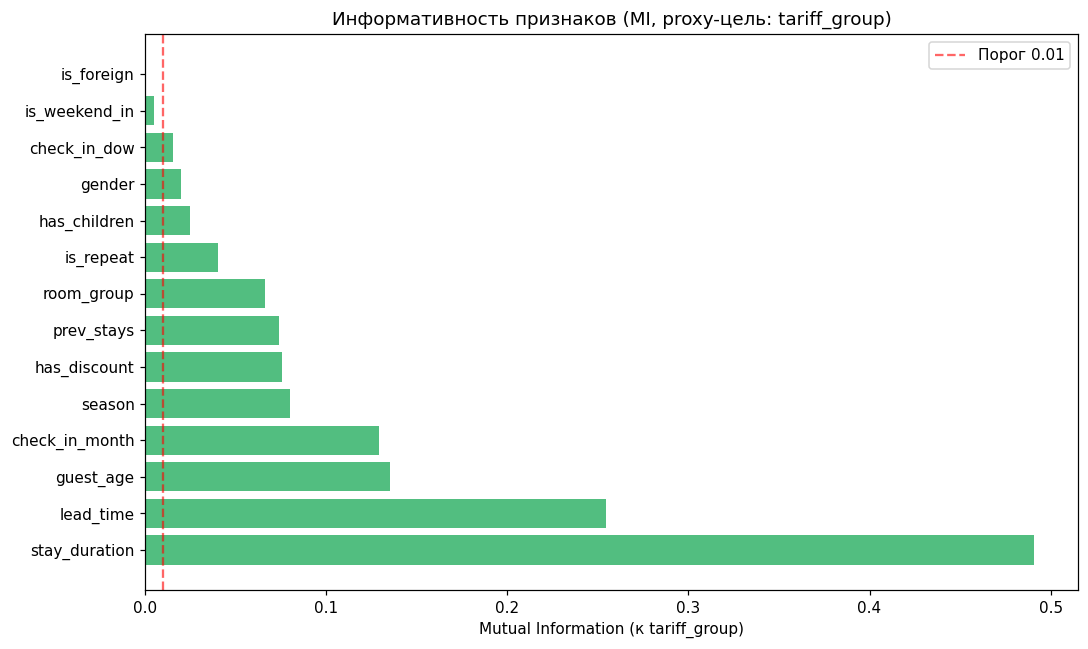

       feature       MI
 stay_duration 0.490600
     lead_time 0.254528
     guest_age 0.135211
check_in_month 0.129135
        season 0.079691
  has_discount 0.075253
    prev_stays 0.073665
    room_group 0.066118
     is_repeat 0.040176
  has_children 0.024683
        gender 0.019540
  check_in_dow 0.015302
 is_weekend_in 0.004558
    is_foreign 0.000113


In [9]:
TARGET_COL = 'tariff_group'

features_for_mi = [c for c in CANDIDATES if c != TARGET_COL]

# Подготовка: imputation + encoding
df_mi = df[features_for_mi + [TARGET_COL]].copy()

# Encode strings
cat_cols_mi = ['season', 'room_group', 'gender']
for col in cat_cols_mi:
    df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

# Fill numerics with median
num_cols_mi = [c for c in features_for_mi if c not in cat_cols_mi]
for col in num_cols_mi:
    df_mi[col] = df_mi[col].fillna(df_mi[col].median())

# Drop rows where target is missing
df_mi = df_mi.dropna(subset=[TARGET_COL])

# Sample для скорости
sample = df_mi.sample(min(50000, len(df_mi)), random_state=42)

X = sample[features_for_mi].values
y = LabelEncoder().fit_transform(sample[TARGET_COL].astype(str))

discrete_mask = [c in ['check_in_month','check_in_dow','season','room_group',
                        'gender','has_discount','is_foreign','has_children',
                        'is_repeat','is_weekend_in'] for c in features_for_mi]

mi = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42)

mi_df = pd.DataFrame({'feature': features_for_mi, 'MI': mi})
mi_df = mi_df.sort_values('MI', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df['feature'], mi_df['MI'], color='#27ae60', alpha=0.8)
ax.axvline(0.01, color='red', linestyle='--', alpha=0.6, label='Порог 0.01')
ax.set_xlabel('Mutual Information (к tariff_group)')
ax.set_title(f'Информативность признаков (MI, proxy-цель: {TARGET_COL})')
ax.legend()
plt.tight_layout()
plt.savefig('feature_mi.png', dpi=120)
plt.show()

print(mi_df.to_string(index=False))

## 8. Feature Importance (Random Forest)

Random Forest по той же proxy-цели даёт более устойчивую оценку важности с учётом нелинейных связей.

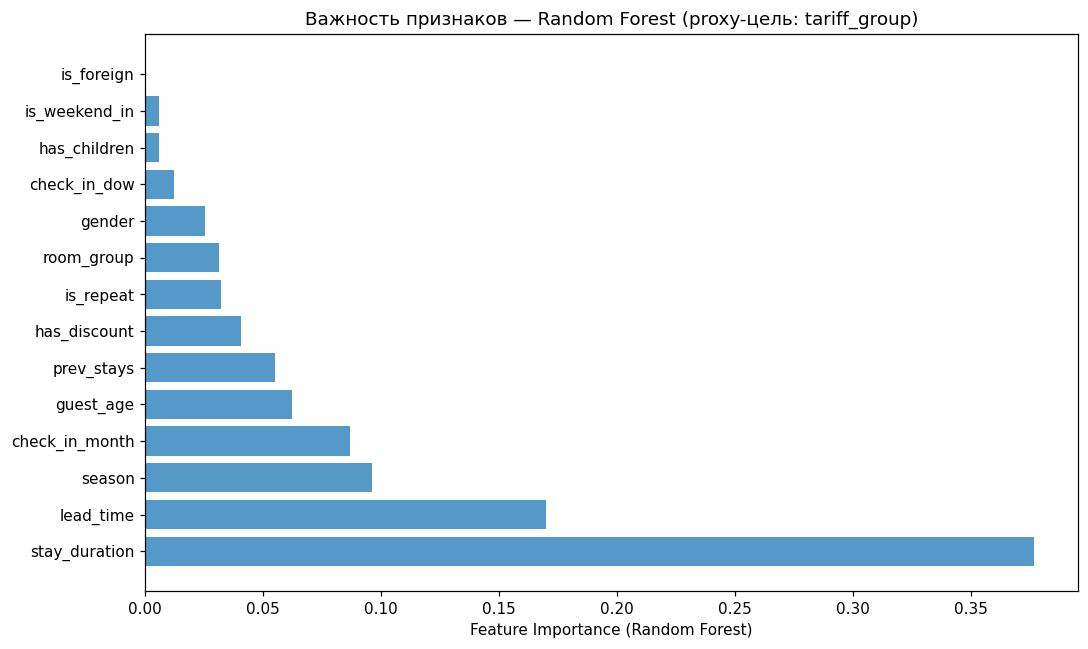

       feature  importance
 stay_duration    0.376647
     lead_time    0.170105
        season    0.096322
check_in_month    0.086749
     guest_age    0.061989
    prev_stays    0.055116
  has_discount    0.040781
     is_repeat    0.031913
    room_group    0.031137
        gender    0.025494
  check_in_dow    0.011950
  has_children    0.005957
 is_weekend_in    0.005767
    is_foreign    0.000073


In [10]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1,
                             random_state=42, class_weight='balanced')
rf.fit(X, y)

fi_df = pd.DataFrame({'feature': features_for_mi, 'importance': rf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color='#2980b9', alpha=0.8)
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title(f'Важность признаков — Random Forest (proxy-цель: {TARGET_COL})')
plt.tight_layout()
plt.savefig('feature_rf_importance.png', dpi=120)
plt.show()

print(fi_df.to_string(index=False))

## 9. Сводная таблица и финальный выбор признаков

In [11]:
# Объединяем все оценки
summary = pd.DataFrame({'feature': list(CANDIDATES.keys()),
                         'description': list(CANDIDATES.values())})
summary['null_pct'] = summary['feature'].map(null_pct).round(1)

mi_map = mi_df.set_index('feature')['MI'].to_dict()
fi_map = fi_df.set_index('feature')['importance'].to_dict()

summary['MI']         = summary['feature'].map(mi_map).round(4)
summary['RF_import']  = summary['feature'].map(fi_map).round(4)

# Нормализуем для итогового скора
for col in ['MI', 'RF_import']:
    mx = summary[col].max()
    summary[col+'_norm'] = (summary[col] / mx).round(3) if mx > 0 else 0

# Штраф за пропуски
summary['null_penalty'] = (summary['null_pct'] / 100).clip(0, 0.5)

# Итоговый скор
summary['score'] = (
    0.45 * summary['MI_norm'] +
    0.45 * summary['RF_import_norm'] -
    0.10 * summary['null_penalty']
).round(3)

summary = summary.sort_values('score', ascending=False)

# Статус отбора
def select_status(row):
    if row['null_pct'] > 50:
        return '⚠ Много пропусков'
    if row['score'] >= 0.30:
        return '✓ ВЫБРАТЬ'
    if row['score'] >= 0.10:
        return '~ Опционально'
    return '✗ Исключить'

summary['decision'] = summary.apply(select_status, axis=1)

print('=' * 90)
print(summary[['feature','null_pct','MI','RF_import','score','decision','description']]
      .to_string(index=False))
print('=' * 90)

       feature  null_pct     MI  RF_import  score      decision                           description
 stay_duration       0.1 0.4906     0.3766  0.900     ✓ ВЫБРАТЬ         Длительность проживания (дни)
     lead_time       0.0 0.2545     0.1701  0.437     ✓ ВЫБРАТЬ Заблаговременность бронирования (дни)
check_in_month       0.0 0.1291     0.0867  0.222 ~ Опционально                   Месяц заезда (1-12)
        season       0.0 0.0797     0.0963  0.188 ~ Опционально                          Сезон заезда
     guest_age      26.2 0.1352     0.0620  0.172 ~ Опционально                         Возраст гостя
  has_discount       0.0 0.0753     0.0408  0.117 ~ Опционально             Наличие скидки (бинарный)
    prev_stays      26.4 0.0737     0.0551  0.107 ~ Опционально             Кол-во предыдущих визитов
    room_group       0.0 0.0661     0.0311  0.098   ✗ Исключить                    Группа типа номера
     is_repeat       0.0 0.0402     0.0319  0.075   ✗ Исключить            Повторн

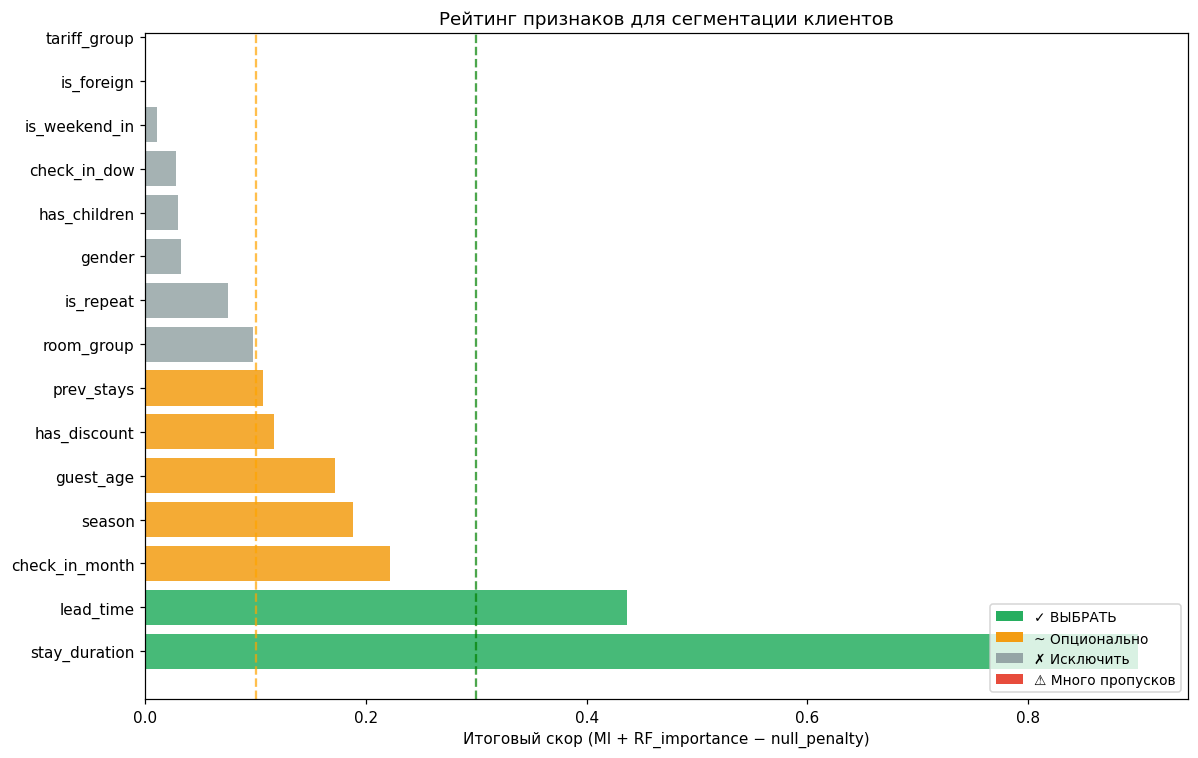

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
colors_map = {'✓ ВЫБРАТЬ': '#27ae60', '~ Опционально': '#f39c12',
              '✗ Исключить': '#95a5a6', '⚠ Много пропусков': '#e74c3c'}
bar_colors = summary['decision'].map(colors_map)

ax.barh(summary['feature'], summary['score'], color=bar_colors, alpha=0.85)
ax.axvline(0.30, color='green', linestyle='--', alpha=0.7, label='Порог выбора (0.30)')
ax.axvline(0.10, color='orange', linestyle='--', alpha=0.7, label='Опциональный (0.10)')
ax.set_xlabel('Итоговый скор (MI + RF_importance − null_penalty)')
ax.set_title('Рейтинг признаков для сегментации клиентов')
ax.legend(loc='lower right')

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor=v, label=k) for k,v in colors_map.items()]
ax.legend(handles=legend_elem, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('feature_final_ranking.png', dpi=120)
plt.show()

## 10. Исключённые признаки — обоснование

In [13]:
print('Признаки, исключённые до анализа (с обоснованием):')
print('-' * 70)
for feat, reason in EXCLUDED.items():
    print(f'  {feat:<30} → {reason}')

Признаки, исключённые до анализа (с обоснованием):
----------------------------------------------------------------------
  grp / grp_norm                 → Технический ID бронирования — не атрибут клиента
  rooms                          → 95% пропусков — нет данных
  extra_places                   → 81% пропусков — нет данных
  children (raw)                 → 92% пропусков → заменён бинарным has_children
  adults (raw)                   → 58% пропусков, почти всегда 1-2 — низкая вариация
  places (raw)                   → 21% пропусков, почти всегда 1 — низкая вариация
  composition                    → 58% пропусков + перекрывается has_children
  citizenship (raw)              → 97% Россия — заменён бинарным is_foreign
  currency                       → 96% Рублей — нет вариации
  tariff (raw)                   → 628 уникальных значений → заменён tariff_group
  room_type (raw)                → 24 значения → заменён room_group
  guest_id / name                → Идентификаторы, не пр

## 11. Итог: финальный набор признаков

### Основной набор (рекомендуется для кластеризации)

| Признак | Описание | Бизнес-смысл для сегментации |
|---------|----------|------------------------------|
| `stay_duration` | Длительность проживания (дни) | Краткосрочные vs долгосрочные гости |
| `lead_time` | Заблаговременность бронирования | Планировщики vs спонтанные |
| `tariff_group` | Группа тарифа | Ценовой сегмент (льготный / коммерческий / all-incl) |
| `room_group` | Группа типа номера | Предпочтения по уровню комфорта |
| `check_in_month` | Месяц заезда | Сезонные паттерны |
| `prev_stays` | Кол-во предыдущих визитов | Уровень лояльности |
| `has_discount` | Наличие скидки | Чувствительность к цене |
| `guest_age` | Возраст | Возрастная группа (молодёжь / средний возраст / пенсионеры) |
| `gender` | Пол | Профиль клиента |

### Опциональные признаки

| Признак | Описание | Примечание |
|---------|----------|------------|
| `is_repeat` | Повторный гость | Дублирует `prev_stays` в бинарном виде — можно использовать вместо него |
| `season` | Сезон заезда | Дублирует `check_in_month`, но читаемее |
| `has_children` | С детьми | Актуален если > 8% заполненности, иначе `children=0` по умолчанию |
| `is_weekend_in` | Заезд в выходные | Полезен для выявления «уикенд-туристов» |
| `is_foreign` | Иностранец | Малая доля (< 3%) — слабо дифференцирует |

---

### Бизнес-интерпретация сегментов (ожидаемые)

После кластеризации по выбранным признакам ожидаются примерно такие сегменты:

1. **«Льготники»** — длинные сроки (14+ дней), тариф ФСС/ГКУ, не чувствительны к маркетингу
2. **«Коммерческие»** — средние сроки (5–10 дней), тариф Ультра/All-incl, высокий доход для санатория
3. **«Уикенд-гости»** — короткие сроки (2–4 дня), заезд в выходные, высокий lead_time
4. **«Семьи с детьми»** — сезон лето, средние сроки, has_children=1
5. **«Лояльные»** — высокий prev_stays, разные тарифы, заполняют межсезонье

**Применение:** Когда модель прогноза выявит недозагруженность (например, март, стандарт/комфорт), маркетинг направит акцию именно на сегменты 3 и 5 — они бронируют заранее и восприимчивы к скидкам (`has_discount=1`).

In [14]:
# Итоговый список для передачи в следующий ноутбук
FINAL_FEATURES = [
    # Числовые (требуют заполнения пропусков перед обучением)
    'stay_duration',
    'lead_time',
    'guest_age',
    'prev_stays',
    # Категориальные (требуют кодирования)
    'tariff_group',
    'room_group',
    'gender',
    'check_in_month',
    # Бинарные (готовы к использованию)
    'has_discount',
    'is_repeat',
    'has_children',
    'is_weekend_in',
]

print('FINAL_FEATURES для кластеризации:')
for i, f in enumerate(FINAL_FEATURES, 1):
    null = df[f].isna().mean()*100
    print(f'  {i:2}. {f:<20} (пропусков: {null:.1f}%)')

print(f'\nИтого: {len(FINAL_FEATURES)} признаков')
print('\nСледующий шаг: 03_clustering.ipynb — K-Means / DBSCAN / Agglomerative + интерпретация кластеров')

FINAL_FEATURES для кластеризации:
   1. stay_duration        (пропусков: 0.1%)
   2. lead_time            (пропусков: 0.0%)


   3. guest_age            (пропусков: 26.2%)
   4. prev_stays           (пропусков: 26.4%)
   5. tariff_group         (пропусков: 0.0%)
   6. room_group           (пропусков: 0.0%)
   7. gender               (пропусков: 16.8%)
   8. check_in_month       (пропусков: 0.0%)
   9. has_discount         (пропусков: 0.0%)
  10. is_repeat            (пропусков: 0.0%)
  11. has_children         (пропусков: 0.0%)
  12. is_weekend_in        (пропусков: 0.0%)

Итого: 12 признаков

Следующий шаг: 03_clustering.ipynb — K-Means / DBSCAN / Agglomerative + интерпретация кластеров
